# WasteZero AI — Sprint 1: Veri Ön İşleme + Keşifsel Veri Analizi

## Veri keşfi

Bulgular:

| Dosya | Boyut | İçerik (gerçek sütunlara göre) |
|---|---|---|
| `Food Demand Forecasting.csv` | ~18,7 MB, 456.548 satır | Haftalık sipariş verisi: `week`, `center_id`, `meal_id`, `checkout_price`, `base_price`, promosyon bayrakları, `num_orders` |
| `restaurant_sales_data.csv` | ~1,3 MB, 10.000 satır | Günlük ürün satışları: `date`, `menu_item_name`, fiyat/maliyet, `quantity_sold`, `has_promotion`, hava durumu |
| `food_wastage_data.csv` | 1.782 satır | Etkinlik bazlı israf verisi: yiyecek türü, hazırlanan miktar, israf miktarı, saklama/mevsim vb. |
| `restaurant_menu_optimization_data.csv` | 1.000 satır | Menü ekonomisi: `MenuCategory`, `MenuItem`, `Price`, `Profitability` (Low/Medium/High) |

### Agent ↔ veri seti eşleştirmesi

| Agent | Görevi | Bu depodaki dosyalar | Orijinal kaynak |
|---|---|---|---|
| **Talep Agent'ı** | Kategori bazlı satış/talep tahmini | `Food Demand Forecasting.csv` (ana) + `restaurant_sales_data.csv` (kategori köprüsü) | Kaggle: `arashnic/food-demand` |
| **Fire/İsraf Agent'ı** | Ürün bazlı israf riski profili | `food_wastage_data.csv` | Kaggle: `trevinhannibal/food-wastage-data-in-restaurant` |
| **Kâr/Fiyat Agent'ı** | Fiyat–kârlılık analizi | `restaurant_menu_optimization_data.csv` | Kaggle: `rabieelkharoua/predict-restaurant-menu-items-profitability` |
| **Orkestratör** | Agent çıktılarını birleştirme | — (veri seti yok; dil modeli) | — |

## Kurulum

Kütüphaneler, klasör yolları ve grafik varsayılanları. Defter `notebooks/` klasöründen çalıştırıldığı için
ham veri `../data/raw`, temiz çıktılar `../data/processed` altındadır.

In [1]:
# Gerekli kutuphaneler ve genel ayarlar
import os
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")  # ders amacli ciktiyi sade tutmak icin

# Klasor yollari (defter notebooks/ klasorunden calistirilir)
RAW = "../data/raw"
PROCESSED = "../data/processed"
os.makedirs(PROCESSED, exist_ok=True)

# Grafik varsayilanlari
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

# Pandas goruntuleme ayarlari
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("Ham veri klasorundeki dosyalar:")
for f in sorted(os.listdir(RAW)):
    size_mb = os.path.getsize(os.path.join(RAW, f)) / 1e6
    print(f"  - {f}  ({size_mb:.2f} MB)")

Ham veri klasorundeki dosyalar:
  - Food Demand Forecasting.csv  (18.73 MB)
  - food_wastage_data.csv  (0.16 MB)
  - restaurant_menu_optimization_data.csv  (0.08 MB)
  - restaurant_sales_data.csv  (1.30 MB)
  - restaurant_sales_data2.csv  (1.30 MB)


## Yardımcı fonksiyonlar

Her veri setinde tekrarlanacak işleri (güvenli dosya okuma, hızlı özet, eksik oranı, kopya tespiti) tek yerde
tanımlıyoruz. `safe_read_csv`, dosya adı değişse bile defterin baştan sona **kırılmadan** çalışmasını sağlar.

In [2]:
def safe_read_csv(filename, **kwargs):
    """RAW klasorunden CSV okur; dosya yoksa defteri kirmadan uyari verir."""
    path = os.path.join(RAW, filename)
    try:
        df = pd.read_csv(path, **kwargs)
        print(f"OK: '{filename}' yuklendi -> {df.shape[0]:,} satir x {df.shape[1]} sutun")
        return df
    except FileNotFoundError:
        print(f"UYARI: '{filename}' bulunamadi. Dosya adi degismis olabilir; data/raw klasorunu kontrol edin.")
        return None


def inspect_df(df, name="veri"):
    """Bir tablonun hizli ozeti: boyut, sutun tipleri, eksikler, ilk satirlar."""
    if df is None:
        print("Incelenecek veri yok.")
        return
    print(f"--- {name} ---")
    print("Boyut:", df.shape)
    print("\nSutun tipleri:")
    print(df.dtypes)
    print("\nEksik deger sayilari:")
    print(df.isna().sum())
    display(df.head(3))


def missing_ratio(df):
    """Sutun bazinda eksik deger orani (%). Eksik yoksa bunu acikca soyler."""
    ratio = (df.isna().mean() * 100).round(2).sort_values(ascending=False)
    return ratio[ratio > 0] if (ratio > 0).any() else "Eksik deger yok."


def file_md5(filename):
    """Dosyanin MD5 ozetini dondurur (kopya dosya tespiti icin)."""
    path = os.path.join(RAW, filename)
    with open(path, "rb") as fh:
        return hashlib.md5(fh.read()).hexdigest()

## Ortak kategori köprüsü: `map_to_category`

Agent'ların ortak dili 5 ürün kategorisidir: **çorba, ana yemek, salata, tatlı, içecek**
(kod içinde ASCII: `corba`, `ana_yemek`, `salata`, `tatli`, `icecek`). Veri setleri farklı restoranlardan ve
ülkelerden geldiği için (Malezya sokak yemekleri, Amerikan menü kalemleri, malzeme grupları) ürün adlarını bu 5
kategoriye eşleyen **anahtar kelime tabanlı** bir fonksiyon kuruyoruz.

Tasarım kararları:
- Anahtar kelimeler **Türkçe + İngilizce**, ayrıca bu veride gerçekten görülen ürün adlarına göre genişletildi
  (`laksa`, `cendol`, `teh`, `rendang`, `nasi` vb.).
- **Kontrol sırası önemlidir:** önce çorba/içecek/tatlı gibi ayırt edici gruplar, sonra ana yemek, en sonda salata.
  Böylece "Vegetable **Stir**-Fry" sebze içerse de ana yemek kalır.
- Başında/sonunda boşluk bırakılan anahtar kelimeler **kelime sınırı** gibi davranır: `" tea"` sayesinde
  "Iced Lemon Tea" içecek olur ama "S**tea**k" olmaz; `" cola"` sayesinde "Cho**cola**te Cake" içecek sayılmaz.
- Hiçbir kural uymazsa **varsayılan `ana_yemek`** atanır (belgelenmiş karar: restoran cirosunun ana gövdesi).

Fonksiyona güvenebilmek için hemen altında örnek ürün adlarıyla bir **öz-test** çalıştırılır.

In [3]:
CATEGORIES = ["corba", "ana_yemek", "salata", "tatli", "icecek"]

# Anahtar kelime kurallari (Turkce + Ingilizce; bu depodaki gercek urun adlarina gore genisletildi).
# Bosluklu anahtar kelimeler kelime siniri gibi davranir (metin iki yanindan boslukla yastiklanir).
CATEGORY_KEYWORDS = {
    "corba":  ["corba", "çorba", "chorba", "soup", "laksa"],
    "icecek": ["icecek", "içecek", "beverage", "drink", " tea", " teh", "çay",
               "coffee", "kahve", " soda", " cola", "lemonade", "limonata", "juice",
               "ayran", " süt ", "milk", "dairy", "latte", "smoothie"],
    "tatli":  ["tatli", "tatlı", "dessert", "cake", "kek", " tart", "tiramisu",
               "baklava", "cendol", "sweet", "fruit", "meyve", "baked", "pudding",
               "sütlaç", "dondurma", "ice cream", "künefe", "helva"],
    "ana_yemek": ["kebap", "kebab", "steak", "chicken", "tavuk", "beef", "köfte",
                  "kofte", "fish", "balık", "shrimp", "karides", " rice", "pilav",
                  "noodle", "pasta", "spaghetti", "burger", "nasi", "roti", "rendang",
                  "tandoori", "toast", "stir", "meat", "alfredo", "scampi", " main",
                  "güveç", "kavurma"],
    "salata": ["salata", "salad", "vegetable", "sebze", "greens", "caprese", "piyaz"],
}
# Kontrol sirasi: ayirt edici gruplar once, salata en sonda (bkz. yukaridaki aciklama)
CHECK_ORDER = ["corba", "icecek", "tatli", "ana_yemek", "salata"]
DEFAULT_CATEGORY = "ana_yemek"  # hicbir kural uymazsa varsayilan (belgelenmis karar)


def map_to_category(name):
    """Urun/yemek adini 5 ortak kategoriden birine esler."""
    if not isinstance(name, str) or not name.strip():
        return DEFAULT_CATEGORY
    text = " " + name.lower().strip() + " "  # bosluklu anahtar kelimeler icin yastikla
    for cat in CHECK_ORDER:
        if any(kw in text for kw in CATEGORY_KEYWORDS[cat]):
            return cat
    return DEFAULT_CATEGORY


# Oz-test: okuyucunun eslemeye guvenmesi icin ornek adlar uzerinde deneriz
test_items = {
    "Mercimek Çorbası": "corba",
    "Mushroom Soup": "corba",
    "Laksa": "corba",
    "Adana Kebap": "ana_yemek",
    "Grilled Steak": "ana_yemek",           # 'steak' icindeki 'tea' tuzagina dusmemeli
    "Vegetable Stir-Fry": "ana_yemek",      # sebzeli de olsa ana yemektir ('stir' kurali)
    "Çoban Salata": "salata",
    "Caprese Salad": "salata",
    "Baklava": "tatli",
    "Chocolate Lava Cake": "tatli",         # icindeki 'cola' tuzagina dusmemeli
    "Sütlaç": "tatli",
    "Fruit Tart": "tatli",
    "Ayran": "icecek",
    "Iced Lemon Tea": "icecek",
    "Teh Tarik": "icecek",
    "Bilinmeyen Urun X": "ana_yemek",       # varsayilan davranis
}
results = pd.DataFrame(
    [(item, map_to_category(item), expected) for item, expected in test_items.items()],
    columns=["urun_adi", "tahmin", "beklenen"],
)
results["dogru_mu"] = results["tahmin"] == results["beklenen"]
print(results.to_string(index=False))
assert results["dogru_mu"].all(), "Kategori eslemesi oz-testi basarisiz!"
print("\nOz-test gecti: tum ornekler beklenen kategoriye eslendi.")

           urun_adi    tahmin  beklenen  dogru_mu
   Mercimek Çorbası     corba     corba      True
      Mushroom Soup     corba     corba      True
              Laksa     corba     corba      True
        Adana Kebap ana_yemek ana_yemek      True
      Grilled Steak ana_yemek ana_yemek      True
 Vegetable Stir-Fry ana_yemek ana_yemek      True
       Çoban Salata    salata    salata      True
      Caprese Salad    salata    salata      True
            Baklava     tatli     tatli      True
Chocolate Lava Cake     tatli     tatli      True
             Sütlaç     tatli     tatli      True
         Fruit Tart     tatli     tatli      True
              Ayran    icecek    icecek      True
     Iced Lemon Tea    icecek    icecek      True
          Teh Tarik    icecek    icecek      True
  Bilinmeyen Urun X ana_yemek ana_yemek      True

Oz-test gecti: tum ornekler beklenen kategoriye eslendi.


## Talep Agent'ı — satış/talep verisi

**Bu veri neyi anlatır?** Talep Agent'ının işi, "yarın hangi kategoriden ne kadar satılır?" sorusuna cevap
vermektir. Bunun için geçmiş sipariş adetleri, fiyat ve promosyon bilgisine ihtiyaç duyar: promosyon talebi ne
kadar artırıyor, fiyat/indirim talebi nasıl etkiliyor, talep zaman içinde nasıl dalgalanıyor?

**Ana kaynak — `Food Demand Forecasting.csv`** (Kaggle: `arashnic/food-demand`): Bir yemek dağıtım şirketinin
**145 haftalık**, 77 merkez x 51 ürünlük sipariş geçmişi. Her satır "bir haftada, bir merkezde, bir ürünün"
kaydıdır: satış fiyatı (`checkout_price`), liste fiyatı (`base_price`), iki promosyon bayrağı
(e-posta kampanyası, ana sayfa vitrini) ve hedefimiz olan sipariş adedi (`num_orders`).

**Keşif bulgusu:** Bu setin `meal_id → category` eşlemesini veren `meal_info.csv` dosyası depoda **yok**.
Aşağıdaki ön işleme adımı bu dosyayı programatik olarak arar; bulamazsa tabloyu kategorisiz temizler ve durumu
Sprint 2 aksiyonu olarak raporlar. Kategori köprüsünü bugün kurabilmek için ürün adı içeren ikinci satış dosyası
(`restaurant_sales_data.csv`, bölüm 3B) ayrıca hazırlanır. (Not: bu ikinci dosyanın kaynağı `DATA_SOURCES.md`
içinde listelenmemiş; kaynağının belgelenmesi de Sprint 2 maddesidir.)

### Ön işleme — Kaggle Food Demand

In [4]:
# --- Kaggle Food Demand: ON ISLEME ---
demand = safe_read_csv("Food Demand Forecasting.csv")
if demand is not None:
    print("Gercek sutunlar:", list(demand.columns))

# Sutun konfigurasyonu -- dosyanin farkli bir surumunde adlar degisirse yalnizca burayi guncelleyin
D_ID_COL    = "id"              # satir kimligi
D_TIME_COL  = "week"            # zaman ekseni (hafta no)
D_STORE_COL = "center_id"       # dagitim merkezi
D_ITEM_COL  = "meal_id"         # urun kimligi (kategori bilgisi ayri dosyada olmali)
D_PRICE_COL = "checkout_price"  # gercek satis fiyati
D_BASEP_COL = "base_price"      # liste fiyati
D_PROMO_COLS = ["emailer_for_promotion", "homepage_featured"]  # promosyon bayraklari
D_TARGET_COL = "num_orders"     # talep hedefi: siparis adedi

OK: 'Food Demand Forecasting.csv' yuklendi -> 456,548 satir x 9 sutun
Gercek sutunlar: ['id', 'week', 'center_id', 'meal_id', 'checkout_price', 'base_price', 'emailer_for_promotion', 'homepage_featured', 'num_orders']


In [5]:
if demand is not None:
    before = demand.shape

    # 1) Eksik deger kontrolu
    print("Eksik deger oranlari:", missing_ratio(demand))

    # 2) Yinelenen satirlar
    dup = int(demand.duplicated().sum())
    demand = demand.drop_duplicates()
    print(f"Yinelenen satir: {dup} (silindi)")

    # 3) Tip duzeltmeleri: 0/1 kodlu promosyon bayraklarini bool yap
    for c in D_PROMO_COLS:
        if c in demand.columns:
            demand[c] = demand[c].astype(bool)

    # 4) Turetilmis ozellikler: indirim orani ve genel promosyon bayragi
    if D_PRICE_COL in demand.columns and D_BASEP_COL in demand.columns:
        demand["discount_rate"] = ((demand[D_BASEP_COL] - demand[D_PRICE_COL]) / demand[D_BASEP_COL]).round(4)
    if all(c in demand.columns for c in D_PROMO_COLS):
        demand["is_promoted"] = demand[D_PROMO_COLS].any(axis=1)

    # 5) Kategori koprusu denemesi: meal_id -> kategori icin meal_info benzeri dosya ara
    meal_info_file = None
    for f in os.listdir(RAW):
        if not f.endswith(".csv") or f == "Food Demand Forecasting.csv":
            continue
        try:
            head_cols = {c.lower() for c in pd.read_csv(os.path.join(RAW, f), nrows=3).columns}
        except Exception:
            continue
        if "meal_id" in head_cols and ("category" in head_cols or "cuisine" in head_cols):
            meal_info_file = f
            break

    if meal_info_file and D_ITEM_COL in demand.columns:
        info = pd.read_csv(os.path.join(RAW, meal_info_file))
        demand = demand.merge(info, on=D_ITEM_COL, how="left")
        print(f"meal_info dosyasi bulundu ve birlestirildi: {meal_info_file}")
    else:
        print("NOT: meal_id -> kategori eslemesi icin meal_info.csv depoda YOK.")
        print("Tablo simdilik kategorisiz temizlenir; kategori koprusu Sprint 2'de bu dosya eklenerek kurulacak.")

    print(f"Boyut: {before} -> {demand.shape}")
    display(demand.head(3))

    # Temiz ciktiyi kaydet
    out_path = os.path.join(PROCESSED, "agent_demand.csv")
    demand.to_csv(out_path, index=False)
    print("Kaydedildi:", out_path)

Eksik deger oranlari: Eksik deger yok.
Yinelenen satir: 0 (silindi)


NOT: meal_id -> kategori eslemesi icin meal_info.csv depoda YOK.
Tablo simdilik kategorisiz temizlenir; kategori koprusu Sprint 2'de bu dosya eklenerek kurulacak.
Boyut: (456548, 9) -> (456548, 11)


,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,discount_rate,is_promoted
0,1379560,1,55,1885,136.83,152.29,False,False,177,0.1015,False
1,1466964,1,55,1993,136.83,135.83,False,False,270,-0.0074,False
2,1346989,1,55,2539,134.86,135.86,False,False,189,0.0074,False


Kaydedildi: ../data/processed\agent_demand.csv


### EDA — Kaggle Food Demand

Talep agent'ının modellemeden önce bilmesi gerekenler: talep dağılımının şekli (çarpık mı?), promosyonun
etkisi ve zaman içindeki seyir.

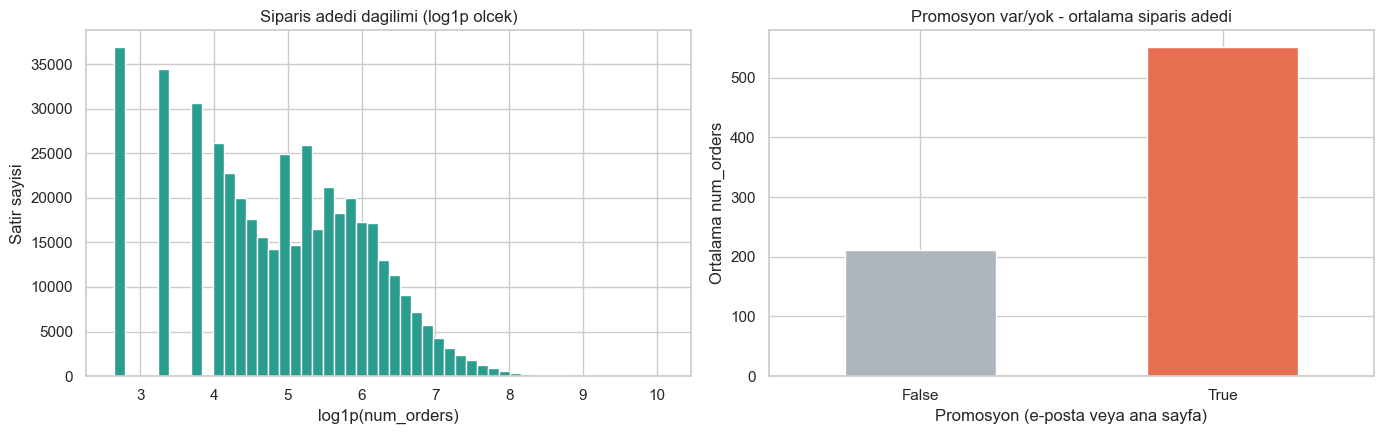

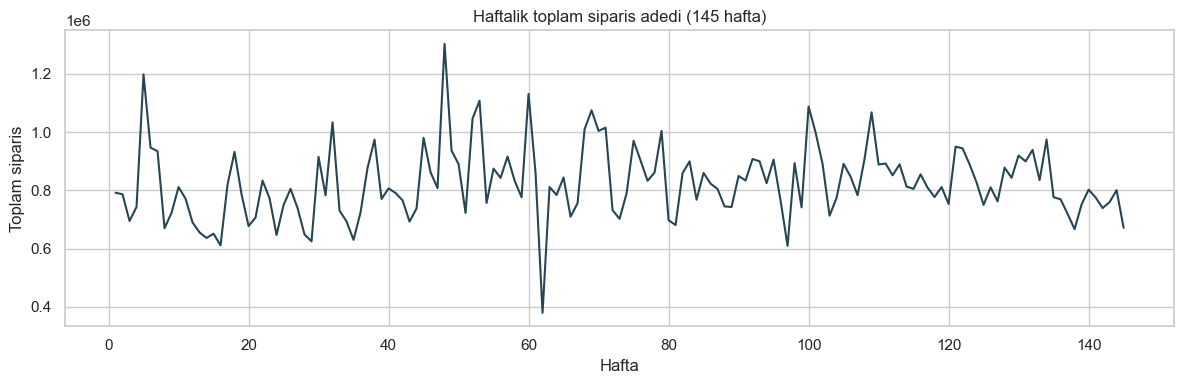

Indirim orani ile siparis adedi arasindaki Spearman korelasyonu: 0.122

Promosyon kiriliminda siparis adedi ozeti:
                count   mean    std   min    25%    50%    75%      max
is_promoted                                                            
False        388874.0  211.4  255.2  13.0   53.0  122.0  283.0   9045.0
True          67674.0  551.8  764.6  13.0  123.0  310.0  663.0  24299.0


In [6]:
# --- 3A) Kaggle Food Demand: EDA ---
if demand is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Talep dagilimi: sag kuyruk cok uzun oldugu icin log1p olcegi kullaniyoruz
    if D_TARGET_COL in demand.columns:
        axes[0].hist(np.log1p(demand[D_TARGET_COL]), bins=50, color="#2a9d8f")
        axes[0].set_title("Siparis adedi dagilimi (log1p olcek)")
        axes[0].set_xlabel("log1p(num_orders)")
        axes[0].set_ylabel("Satir sayisi")

    # Promosyonun talebe etkisi
    if "is_promoted" in demand.columns and D_TARGET_COL in demand.columns:
        promo_mean = demand.groupby("is_promoted")[D_TARGET_COL].mean()
        promo_mean.plot(kind="bar", ax=axes[1], color=["#adb5bd", "#e76f51"], rot=0)
        axes[1].set_title("Promosyon var/yok - ortalama siparis adedi")
        axes[1].set_xlabel("Promosyon (e-posta veya ana sayfa)")
        axes[1].set_ylabel("Ortalama num_orders")
    plt.tight_layout()
    plt.show()

    # Haftalik toplam talep: zaman serisi karakteri (trend/dalgalanma) gorunur olsun
    if D_TIME_COL in demand.columns and D_TARGET_COL in demand.columns:
        weekly = demand.groupby(D_TIME_COL)[D_TARGET_COL].sum()
        plt.figure(figsize=(12, 4))
        weekly.plot(color="#264653")
        plt.title("Haftalik toplam siparis adedi (145 hafta)")
        plt.xlabel("Hafta")
        plt.ylabel("Toplam siparis")
        plt.tight_layout()
        plt.show()

    # Indirim-talep iliskisi: dagilim carpik oldugu icin Spearman (siralama) korelasyonu
    if "discount_rate" in demand.columns and D_TARGET_COL in demand.columns:
        corr = demand["discount_rate"].corr(demand[D_TARGET_COL], method="spearman")
        print(f"Indirim orani ile siparis adedi arasindaki Spearman korelasyonu: {corr:.3f}")
    if "is_promoted" in demand.columns and D_TARGET_COL in demand.columns:
        print("\nPromosyon kiriliminda siparis adedi ozeti:")
        print(demand.groupby("is_promoted")[D_TARGET_COL].describe().round(1))

### 3B — İkinci talep verisi: `restaurant_sales_data.csv` (kategori köprülü)

Bu dosya, ürün **adı** içeren günlük satış kayıtlarıdır (2024 boyunca, 10.000 satır): Malezya/Singapur mutfağından
14 ürün, satış adedi, gerçek satış fiyatı, malzeme maliyeti, promosyon ve hava durumu. `meal_info.csv` eksik olduğu
için 5 ortak kategoriye **bugün** bağlanabilen tek talep verisi budur — Talep Agent'ının orkestratörle
konuşacağı kategori dilini bu tablo üzerinden kuruyoruz.

Önce `restaurant_sales_data2.csv` dosyasının gerçekten kopya olduğunu MD5 ile kanıtlıyoruz, sonra tek dosyayla
devam ediyoruz.

### 3B.1 Ön işleme

In [7]:
# --- 3B) restaurant_sales_data: ON ISLEME ---
# Kopya dosya kontrolu: iki satis dosyasinin MD5 ozetini karsilastir
try:
    h1 = file_md5("restaurant_sales_data.csv")
    h2 = file_md5("restaurant_sales_data2.csv")
    print("restaurant_sales_data.csv  MD5:", h1)
    print("restaurant_sales_data2.csv MD5:", h2)
    print("Ayni dosya mi? ->", h1 == h2, "(ayniysa yalnizca ilkini kullaniriz)")
except FileNotFoundError as e:
    print("Kopya kontrolu atlandi:", e)

sales = safe_read_csv("restaurant_sales_data.csv")
if sales is not None:
    print("Gercek sutunlar:", list(sales.columns))

# Sutun konfigurasyonu -- adlar degisirse yalnizca burayi guncelleyin
S_DATE_COL  = "date"                    # satis gunu (AA/GG/YYYY formatinda geldi)
S_ITEM_COL  = "menu_item_name"          # urun adi -> kategori eslemesi buradan yapilir
S_QTY_COL   = "quantity_sold"           # talep hedefi: satilan adet
S_PRICE_COL = "actual_selling_price"    # gercek satis fiyati
S_COST_COL  = "typical_ingredient_cost" # malzeme maliyeti
S_PROMO_COL = "has_promotion"           # promosyon bayragi

restaurant_sales_data.csv  MD5: 1009e23508517ea10143b25e7ec0dcb2
restaurant_sales_data2.csv MD5: 1009e23508517ea10143b25e7ec0dcb2
Ayni dosya mi? -> True (ayniysa yalnizca ilkini kullaniriz)
OK: 'restaurant_sales_data.csv' yuklendi -> 10,000 satir x 13 sutun
Gercek sutunlar: ['date', 'restaurant_id', 'restaurant_type', 'menu_item_name', 'meal_type', 'key_ingredients_tags', 'typical_ingredient_cost', 'observed_market_price', 'actual_selling_price', 'quantity_sold', 'has_promotion', 'special_event', 'weather_condition']


In [8]:
if sales is not None:
    before = sales.shape

    # 1) Eksik degerler ve yinelenen satirlar
    print("Eksik deger oranlari:", missing_ratio(sales))
    dup = int(sales.duplicated().sum())
    sales = sales.drop_duplicates()
    print(f"Yinelenen satir: {dup} (silindi)")

    # 2) Tarih tipini duzelt: metin -> datetime (ay/gun/yil; aralik 2024-01-01 -> 2025-01-01)
    if S_DATE_COL in sales.columns:
        sales[S_DATE_COL] = pd.to_datetime(sales[S_DATE_COL], format="%m/%d/%Y")
        sales["year_month"] = sales[S_DATE_COL].dt.to_period("M").astype(str)  # aylik EDA icin
        print("Tarih araligi:", sales[S_DATE_COL].min().date(), "->", sales[S_DATE_COL].max().date())

    # 3) Urun adlarini 5 ortak kategoriye esle (kopru sutunu)
    if S_ITEM_COL in sales.columns:
        sales["category"] = sales[S_ITEM_COL].map(map_to_category)
        print("\nUrun -> kategori eslemesi (seffaflik icin tam liste):")
        mapping = sales.drop_duplicates(S_ITEM_COL)[[S_ITEM_COL, "category"]].sort_values(["category", S_ITEM_COL])
        print(mapping.to_string(index=False))

    print(f"\nBoyut: {before} -> {sales.shape}")
    display(sales.head(3))

    out_path = os.path.join(PROCESSED, "agent_demand_category.csv")
    sales.to_csv(out_path, index=False)
    print("Kaydedildi:", out_path)

Eksik deger oranlari: Eksik deger yok.
Yinelenen satir: 0 (silindi)
Tarih araligi: 2024-01-01 -> 2025-01-01

Urun -> kategori eslemesi (seffaflik icin tam liste):
     menu_item_name  category
       Beef Rendang ana_yemek
     Char Kway Teow ana_yemek
       Chicken Chop ana_yemek
       Chicken Rice ana_yemek
     Kaya Toast Set ana_yemek
         Nasi Lemak ana_yemek
         Roti Canai ana_yemek
Spaghetti Carbonara ana_yemek
   Tandoori Chicken ana_yemek
              Laksa     corba
      Mushroom Soup     corba
     Iced Lemon Tea    icecek
          Teh Tarik    icecek
             Cendol     tatli

Boyut: (10000, 13) -> (10000, 15)


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition,year_month,category
0,2024-01-01,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny,2024-01,corba
1,2024-01-01,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny,2024-01,ana_yemek
2,2024-01-01,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy,2024-01,ana_yemek


Kaydedildi: ../data/processed\agent_demand_category.csv


### 3B.2 EDA — kategori bazlı talep, promosyon ve trend

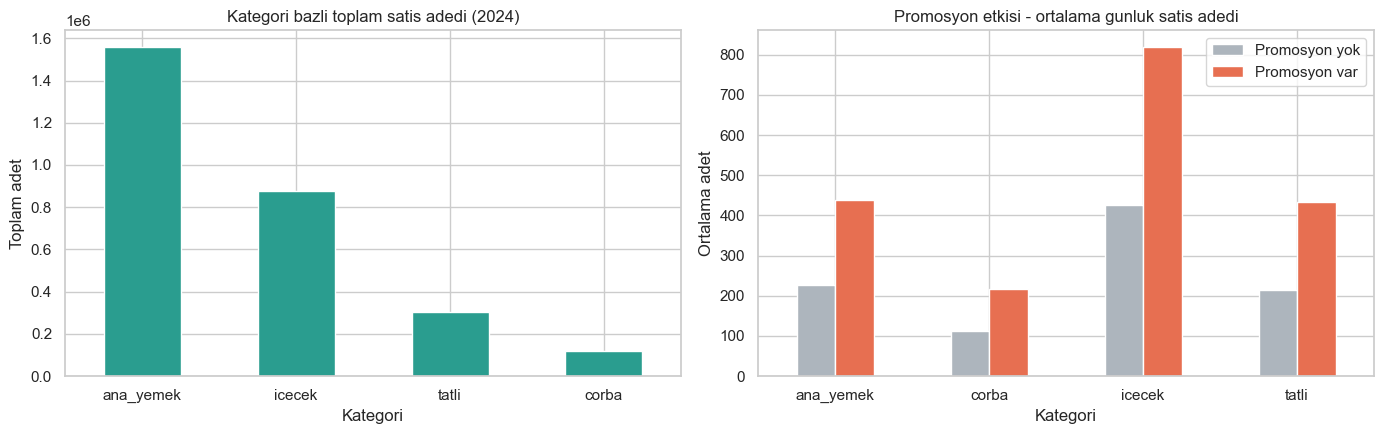

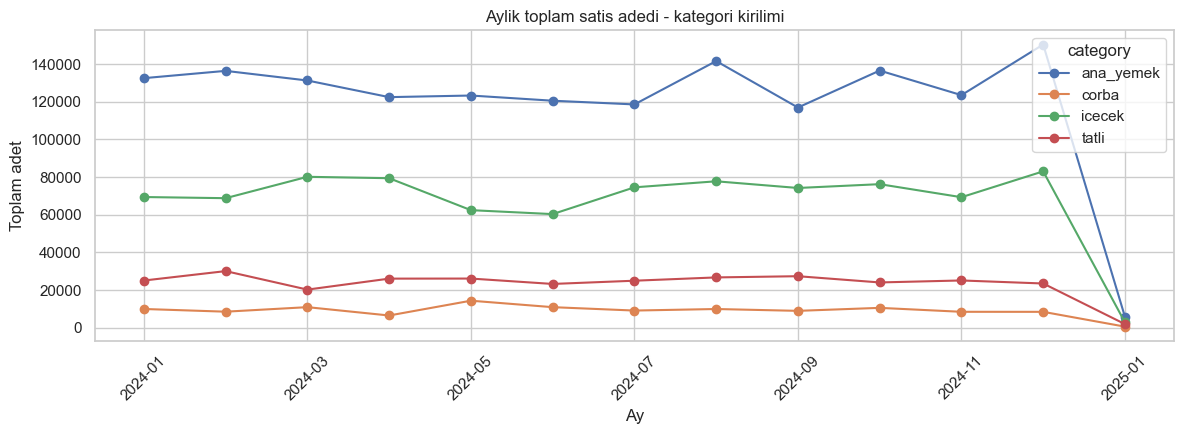

Fiyat-talep Spearman korelasyonu: -0.690 (negatif deger: fiyat arttikca adet duser)


In [9]:
# --- 3B) restaurant_sales_data: EDA ---
if sales is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Kategori bazli toplam talep: hangi kategori cironun govdesi?
    if "category" in sales.columns and S_QTY_COL in sales.columns:
        cat_qty = sales.groupby("category")[S_QTY_COL].sum().sort_values(ascending=False)
        cat_qty.plot(kind="bar", ax=axes[0], color="#2a9d8f", rot=0)
        axes[0].set_title("Kategori bazli toplam satis adedi (2024)")
        axes[0].set_xlabel("Kategori")
        axes[0].set_ylabel("Toplam adet")

    # Promosyonun kategori bazli etkisi
    if all(c in sales.columns for c in ["category", S_PROMO_COL, S_QTY_COL]):
        promo_cat = sales.groupby(["category", S_PROMO_COL])[S_QTY_COL].mean().unstack()
        promo_cat.plot(kind="bar", ax=axes[1], rot=0, color=["#adb5bd", "#e76f51"])
        axes[1].set_title("Promosyon etkisi - ortalama gunluk satis adedi")
        axes[1].set_xlabel("Kategori")
        axes[1].set_ylabel("Ortalama adet")
        axes[1].legend(["Promosyon yok", "Promosyon var"])
    plt.tight_layout()
    plt.show()

    # Aylik talep trendi (kategori kirilimi): mevsimsellik ipuclari
    if all(c in sales.columns for c in ["year_month", "category", S_QTY_COL]):
        trend = sales.groupby(["year_month", "category"])[S_QTY_COL].sum().unstack()
        ax = trend.plot(figsize=(12, 4.5), marker="o")
        ax.set_title("Aylik toplam satis adedi - kategori kirilimi")
        ax.set_xlabel("Ay")
        ax.set_ylabel("Toplam adet")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Fiyat-talep iliskisi
    if S_PRICE_COL in sales.columns and S_QTY_COL in sales.columns:
        corr = sales[S_PRICE_COL].corr(sales[S_QTY_COL], method="spearman")
        print(f"Fiyat-talep Spearman korelasyonu: {corr:.3f} (negatif deger: fiyat arttikca adet duser)")

## 4) Fire/İsraf Agent'ı — `food_wastage_data.csv`

**Bu veri neyi anlatır?** İsraf Agent'ının işi, "bu kategoride fazla üretirsek ne kadarı çöpe gider?" sorusuna
cevap vermektir. Kaynak: Kaggle `trevinhannibal/food-wastage-data-in-restaurant`. Her satır bir etkinliğin
(düğün, kurumsal, doğum günü, sosyal) kaydıdır: misafir sayısı, **hazırlanan miktar** (`Quantity of Food`),
**israf edilen miktar** (`Wastage Food Amount`) ve israfı etkileyen koşullar (saklama, mevsim, servis yöntemi,
konum, fiyat seviyesi).

**Önemli sınırlama (dürüst not):** Bu set yemek adı değil, **malzeme grubu** içerir
(Meat, Vegetables, Fruits, Dairy Products, Baked Goods). 5 ortak kategoriye eşleme bu yüzden **yaklaşıktır** ve
varsayımları aşağıda belgelenmiştir; `corba` bu sette hiç temsil edilmez. Orijinal `food_type` sütunu
kaybolmasın diye temiz çıktıda korunur.

| `food_type` | Kategori | Gerekçe |
|---|---|---|
| Meat | `ana_yemek` | Et bazlı ana yemekler |
| Vegetables | `salata` | Sebze/salata grubu |
| Fruits | `tatli` | Meyve/tatlı grubu |
| Baked Goods | `tatli` | Unlu/pastane ürünleri tatlı grubuna en yakın |
| Dairy Products | `icecek` | Süt bazlı ürünler içecek grubuna en yakın |

### 4.1 Ön işleme

In [10]:
# --- 4) Fire/Israf verisi: ON ISLEME ---
waste = safe_read_csv("food_wastage_data.csv")
if waste is not None:
    print("Gercek sutunlar:", list(waste.columns))

# Sutun adlarini standartlastir: bosluklu Ingilizce adlar -> snake_case
WASTE_RENAME = {
    "Type of Food": "food_type",              # malzeme grubu (kategori eslemesi buradan)
    "Number of Guests": "num_guests",
    "Event Type": "event_type",
    "Quantity of Food": "quantity_prepared",  # hazirlanan miktar
    "Storage Conditions": "storage",
    "Purchase History": "purchase_history",
    "Seasonality": "seasonality",
    "Preparation Method": "prep_method",
    "Geographical Location": "geo_location",
    "Pricing": "pricing_level",               # metinsel fiyat seviyesi (Low/Moderate/High)
    "Wastage Food Amount": "wastage_amount",  # israf edilen miktar (hedef)
}
W_QTY_COL   = "quantity_prepared"
W_WASTE_COL = "wastage_amount"

OK: 'food_wastage_data.csv' yuklendi -> 1,782 satir x 11 sutun
Gercek sutunlar: ['Type of Food', 'Number of Guests', 'Event Type', 'Quantity of Food', 'Storage Conditions', 'Purchase History', 'Seasonality', 'Preparation Method', 'Geographical Location', 'Pricing', 'Wastage Food Amount']


In [11]:
if waste is not None:
    before = waste.shape
    waste = waste.rename(columns=WASTE_RENAME)

    # 1) Eksik degerler
    print("Eksik deger oranlari:", missing_ratio(waste))

    # 2) Yinelenen satirlar (kesifte 164 kopya satir tespit edilmisti)
    dup = int(waste.duplicated().sum())
    waste = waste.drop_duplicates()
    print(f"Yinelenen satir: {dup} (silindi)")

    # 3) Metinsel sirali degiskeni sayiya cevir: ortalama alinabilsin diye
    if "pricing_level" in waste.columns:
        waste["pricing_score"] = waste["pricing_level"].map({"Low": 1, "Moderate": 2, "High": 3})

    # 4) Kategori koprusu: malzeme grubu -> 5 ortak kategori (yaklasik esleme, gerekce ustteki tabloda)
    if "food_type" in waste.columns:
        waste["category"] = waste["food_type"].map(map_to_category)
        print("\nfood_type -> kategori eslemesi:")
        print(waste.drop_duplicates("food_type")[["food_type", "category"]].to_string(index=False))

    # 5) Turetilmis ozellik: israf orani = israf / hazirlanan (kategoriler arasi karsilastirma icin)
    if W_QTY_COL in waste.columns and W_WASTE_COL in waste.columns:
        waste["waste_ratio"] = (waste[W_WASTE_COL] / waste[W_QTY_COL]).round(4)

    print(f"\nBoyut: {before} -> {waste.shape}")
    display(waste.head(3))

    out_path = os.path.join(PROCESSED, "agent_waste.csv")
    waste.to_csv(out_path, index=False)
    print("Kaydedildi:", out_path)

Eksik deger oranlari: Eksik deger yok.
Yinelenen satir: 164 (silindi)

food_type -> kategori eslemesi:
     food_type  category
          Meat ana_yemek
    Vegetables    salata
        Fruits     tatli
   Baked Goods     tatli
Dairy Products    icecek

Boyut: (1782, 11) -> (1618, 14)


,food_type,num_guests,event_type,quantity_prepared,storage,purchase_history,seasonality,prep_method,geo_location,pricing_level,wastage_amount,pricing_score,category,waste_ratio
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25,1,ana_yemek,0.0556
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40,3,ana_yemek,0.0800
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27,1,salata,0.0728


Kaydedildi: ../data/processed\agent_waste.csv


### 4.2 EDA — israf nerede yoğunlaşıyor?

İsraf Agent'ı için kritik sorular: israf miktarının dağılımı, kategori bazlı israf **oranı** (mutlak miktar
büyük etkinliklerde doğal olarak yüksektir, oran daha adil bir kıyas verir) ve israfı büyüten koşullar.

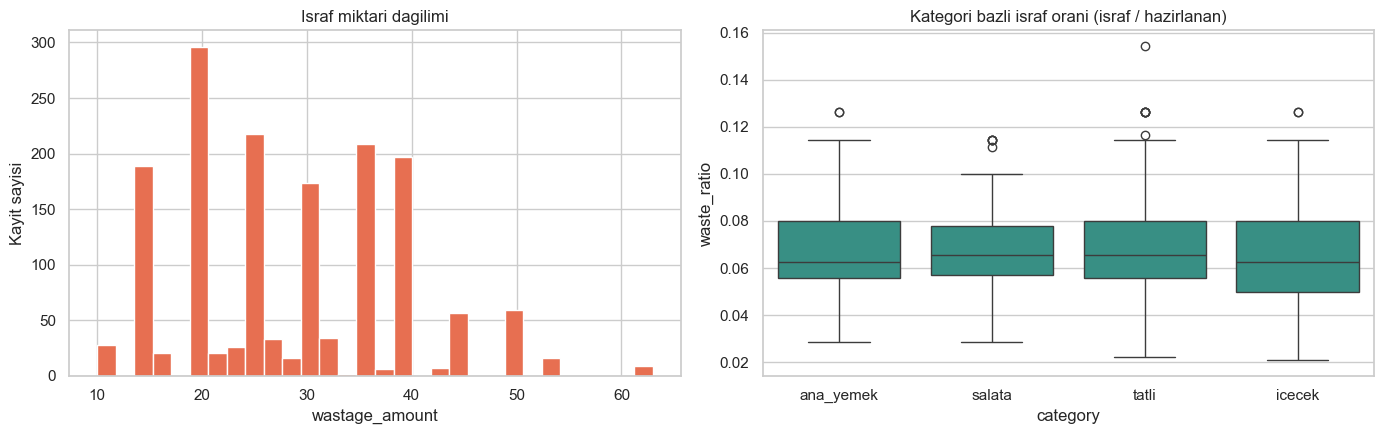

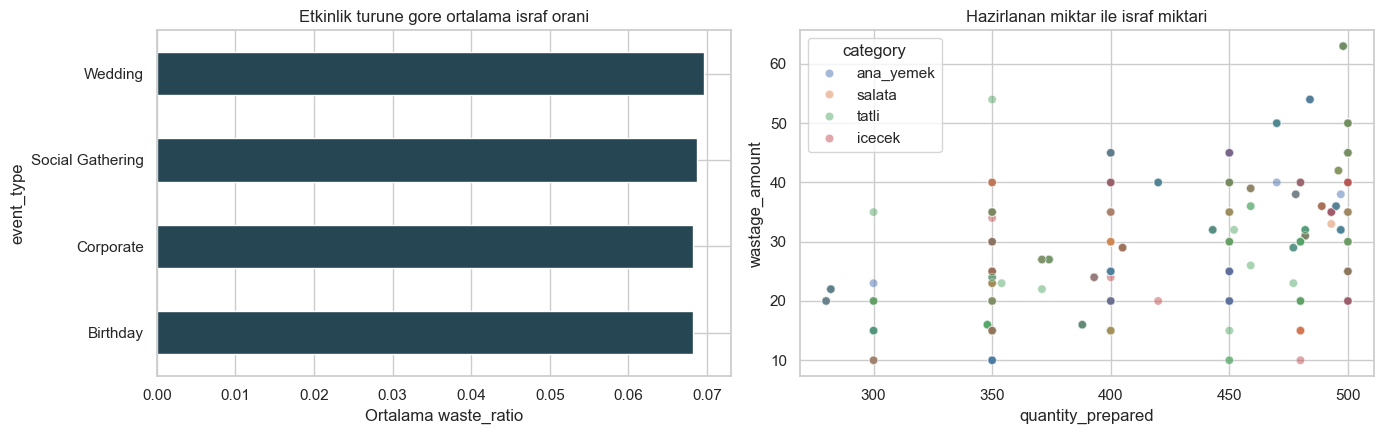

Kategori bazli ortalama israf orani:
category
tatli        0.069
ana_yemek    0.068
icecek       0.068
salata       0.068
Name: waste_ratio, dtype: float64

Saklama kosuluna gore ortalama israf orani:
storage
Refrigerated        0.069
Room Temperature    0.069
Name: waste_ratio, dtype: float64


In [12]:
# --- 4) Fire/Israf verisi: EDA ---
if waste is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Israf miktari dagilimi
    if W_WASTE_COL in waste.columns:
        axes[0].hist(waste[W_WASTE_COL], bins=30, color="#e76f51")
        axes[0].set_title("Israf miktari dagilimi")
        axes[0].set_xlabel("wastage_amount")
        axes[0].set_ylabel("Kayit sayisi")

    # Kategori bazli israf orani
    if all(c in waste.columns for c in ["category", "waste_ratio"]):
        sns.boxplot(data=waste, x="category", y="waste_ratio", ax=axes[1], color="#2a9d8f")
        axes[1].set_title("Kategori bazli israf orani (israf / hazirlanan)")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Etkinlik turune gore ortalama israf orani
    if all(c in waste.columns for c in ["event_type", "waste_ratio"]):
        waste.groupby("event_type")["waste_ratio"].mean().sort_values().plot(
            kind="barh", ax=axes[0], color="#264653")
        axes[0].set_title("Etkinlik turune gore ortalama israf orani")
        axes[0].set_xlabel("Ortalama waste_ratio")

    # Hazirlanan miktar ile israf iliskisi: fazla uretim israfi nasil buyutuyor?
    if all(c in waste.columns for c in [W_QTY_COL, W_WASTE_COL, "category"]):
        sns.scatterplot(data=waste, x=W_QTY_COL, y=W_WASTE_COL, hue="category",
                        alpha=0.5, ax=axes[1])
        axes[1].set_title("Hazirlanan miktar ile israf miktari")
    plt.tight_layout()
    plt.show()

    # Ozet tablolar
    if all(c in waste.columns for c in ["category", "waste_ratio"]):
        print("Kategori bazli ortalama israf orani:")
        print(waste.groupby("category")["waste_ratio"].mean().round(3).sort_values(ascending=False))
    if all(c in waste.columns for c in ["storage", "waste_ratio"]):
        print("\nSaklama kosuluna gore ortalama israf orani:")
        print(waste.groupby("storage")["waste_ratio"].mean().round(3))

## 5) Kâr/Fiyat Agent'ı — `restaurant_menu_optimization_data.csv`

**Bu veri neyi anlatır?** Kâr Agent'ının işi, "bu kategori/ürün fiyatına değiyor mu?" sorusuna cevap vermektir.
Kaynak: Kaggle `rabieelkharoua/predict-restaurant-menu-items-profitability`. 3 restorandan 1.000 menü kaydı:
menü kategorisi (Appetizers/Beverages/Desserts/Main Course), ürün adı, fiyat ve **kârlılık etiketi**
(`Low`/`Medium`/`High` — metinsel sıralı değişken).

İki ön işleme kararı öne çıkar:
1. **Kârlılık ordinal'e çevrilir** (`Low=1, Medium=2, High=3`): metin haliyle ortalaması alınamaz; sayısal skor
   kategori karşılaştırmasına izin verir.
2. **Kategori eşlemesi iki aşamalıdır:** `MenuCategory` güçlü bir sinyaldir (Beverages → `icecek`,
   Desserts → `tatli`, Main Course → `ana_yemek`); yalnızca `Appetizers` belirsizdir ve ürün adı üzerinden
   `map_to_category` ile çözülür (örn. Caprese Salad → `salata`; adı ipucu vermeyen mezeler belgelenmiş
   varsayılanla `ana_yemek`).

Veri kalitesi notu: `Ingredients` sütununda bir kısım kayıt `['confidential']` değerindedir (gizlenmiş içerik);
bunu bir bayrakla işaretleyip sütunu olduğu gibi bırakıyoruz.

### 5.1 Ön işleme

In [13]:
# --- 5) Kar/Fiyat verisi: ON ISLEME ---
menu = safe_read_csv("restaurant_menu_optimization_data.csv")
if menu is not None:
    print("Gercek sutunlar:", list(menu.columns))

# Sutun adlarini standartlastir: CamelCase -> snake_case
MENU_RENAME = {
    "RestaurantID": "restaurant_id",
    "MenuCategory": "menu_category",
    "MenuItem": "item_name",
    "Ingredients": "ingredients",
    "Price": "price",
    "Profitability": "profitability",
}
P_PRICE_COL  = "price"          # menu fiyati
P_PROFIT_COL = "profitability"  # karlilik etiketi (Low/Medium/High)

# Menu kategorisinden ortak kategoriye dogrudan esleme (Appetizers bilerek yok: urun adiyla cozulur)
MENU_CAT_MAP = {"Beverages": "icecek", "Desserts": "tatli", "Main Course": "ana_yemek"}

OK: 'restaurant_menu_optimization_data.csv' yuklendi -> 1,000 satir x 6 sutun
Gercek sutunlar: ['RestaurantID', 'MenuCategory', 'MenuItem', 'Ingredients', 'Price', 'Profitability']


In [14]:
if menu is not None:
    before = menu.shape
    menu = menu.rename(columns=MENU_RENAME)

    # 1) Eksik degerler ve yinelenen satirlar (kesifte 27 kopya satir tespit edilmisti)
    print("Eksik deger oranlari:", missing_ratio(menu))
    dup = int(menu.duplicated().sum())
    menu = menu.drop_duplicates()
    print(f"Yinelenen satir: {dup} (silindi)")

    # 2) Veri kalitesi bayragi: icerigi gizlenmis kayitlar
    if "ingredients" in menu.columns:
        menu["ingredients_hidden"] = menu["ingredients"].str.contains("confidential", case=False, na=False)
        print(f"Icerigi 'confidential' olan kayit: {int(menu['ingredients_hidden'].sum())}")

    # 3) Metinsel sirali karlilik etiketini sayisal skora cevir
    if P_PROFIT_COL in menu.columns:
        menu["profitability_score"] = menu[P_PROFIT_COL].map({"Low": 1, "Medium": 2, "High": 3})

    # 4) Kategori koprusu: once menu kategorisi, Appetizers icin urun adi
    if "menu_category" in menu.columns and "item_name" in menu.columns:
        menu["category"] = [
            MENU_CAT_MAP.get(mc) or map_to_category(item)
            for mc, item in zip(menu["menu_category"], menu["item_name"])
        ]
        print("\nMenu kategorisi x ortak kategori dagilimi:")
        print(pd.crosstab(menu["menu_category"], menu["category"]))
        print("\nAppetizers urunlerinin cozumu:")
        appet = menu[menu["menu_category"] == "Appetizers"].drop_duplicates("item_name")
        print(appet[["item_name", "category"]].to_string(index=False))

    print(f"\nBoyut: {before} -> {menu.shape}")
    display(menu.head(3))

    out_path = os.path.join(PROCESSED, "agent_profit.csv")
    menu.to_csv(out_path, index=False)
    print("Kaydedildi:", out_path)

Eksik deger oranlari: Eksik deger yok.
Yinelenen satir: 27 (silindi)
Icerigi 'confidential' olan kayit: 248

Menu kategorisi x ortak kategori dagilimi:
category       ana_yemek  icecek  salata  tatli
menu_category                                  
Appetizers           183       0      65      0
Beverages              0     248       0      0
Desserts               0       0       0    253
Main Course          224       0       0      0

Appetizers urunlerinin cozumu:
            item_name  category
Spinach Artichoke Dip ana_yemek
    Stuffed Mushrooms ana_yemek
           Bruschetta ana_yemek
        Caprese Salad    salata

Boyut: (1000, 6) -> (973, 9)


,restaurant_id,menu_category,item_name,ingredients,price,profitability,ingredients_hidden,profitability_score,category
0,R003,Beverages,Soda,['confidential'],2.55,Low,True,1,icecek
1,R001,Appetizers,Spinach Artichoke Dip,"['Tomatoes', 'Basil', 'Garlic', 'Olive Oil']",11.12,Medium,False,2,ana_yemek
2,R003,Desserts,New York Cheesecake,"['Chocolate', 'Butter', 'Sugar', 'Eggs']",18.66,High,False,3,tatli


Kaydedildi: ../data/processed\agent_profit.csv


### 5.2 EDA — hangi kategori kârlı?

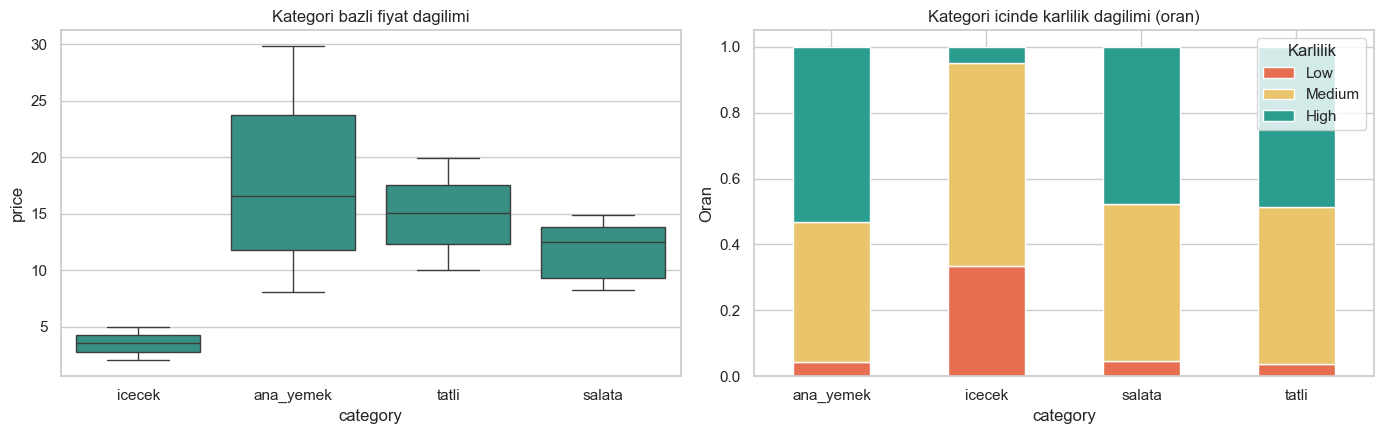

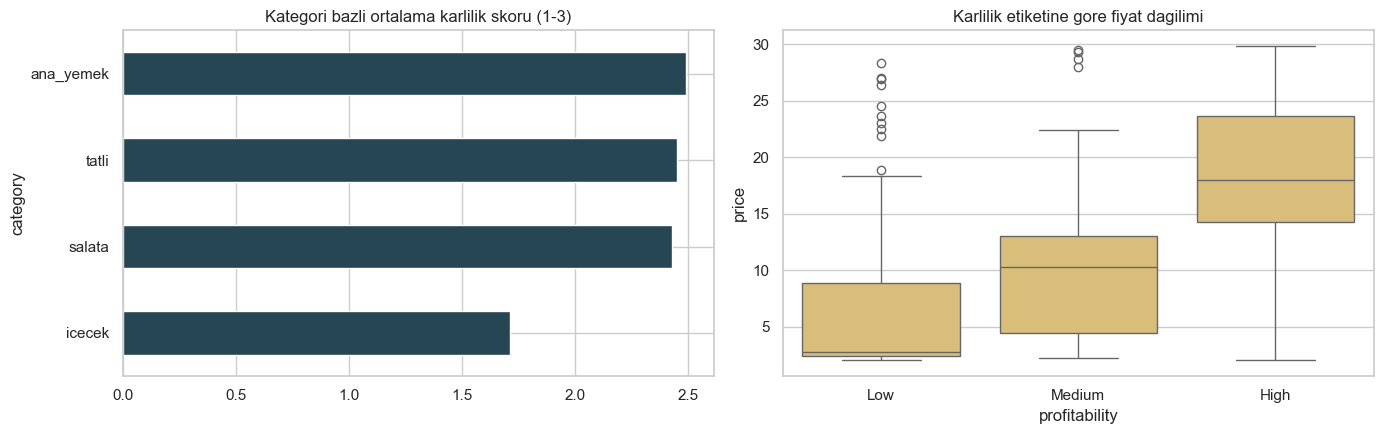

Kategori bazli fiyat-karlilik ozeti:
           urun_sayisi  ort_fiyat  ort_karlilik_skoru
category                                             
ana_yemek          407      17.66                2.49
tatli              253      14.97                2.45
salata              65      11.85                2.43
icecek             248       3.51                1.71


In [15]:
# --- 5) Kar/Fiyat verisi: EDA ---
if menu is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Kategori bazli fiyat dagilimi
    if all(c in menu.columns for c in ["category", P_PRICE_COL]):
        sns.boxplot(data=menu, x="category", y=P_PRICE_COL, ax=axes[0], color="#2a9d8f")
        axes[0].set_title("Kategori bazli fiyat dagilimi")

    # Kategori icinde karlilik etiketi dagilimi (oran)
    if all(c in menu.columns for c in ["category", P_PROFIT_COL]):
        ct = pd.crosstab(menu["category"], menu[P_PROFIT_COL], normalize="index")
        ct = ct.reindex(columns=["Low", "Medium", "High"]).fillna(0)
        ct.plot(kind="bar", stacked=True, ax=axes[1], rot=0,
                color=["#e76f51", "#e9c46a", "#2a9d8f"])
        axes[1].set_title("Kategori icinde karlilik dagilimi (oran)")
        axes[1].set_ylabel("Oran")
        axes[1].legend(title="Karlilik")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Ortalama karlilik skoru (1=Low, 2=Medium, 3=High)
    if all(c in menu.columns for c in ["category", "profitability_score"]):
        menu.groupby("category")["profitability_score"].mean().sort_values().plot(
            kind="barh", ax=axes[0], color="#264653")
        axes[0].set_title("Kategori bazli ortalama karlilik skoru (1-3)")

    # Fiyat ile karlilik iliskisi: pahali urun daha mi karli?
    if all(c in menu.columns for c in [P_PROFIT_COL, P_PRICE_COL]):
        sns.boxplot(data=menu, x=P_PROFIT_COL, y=P_PRICE_COL,
                    order=["Low", "Medium", "High"], ax=axes[1], color="#e9c46a")
        axes[1].set_title("Karlilik etiketine gore fiyat dagilimi")
    plt.tight_layout()
    plt.show()

    # Ozet tablo: kategori bazli fiyat ve karlilik
    if all(c in menu.columns for c in ["category", P_PRICE_COL, "profitability_score"]):
        summary = menu.groupby("category").agg(
            urun_sayisi=("category", "size"),
            ort_fiyat=(P_PRICE_COL, "mean"),
            ort_karlilik_skoru=("profitability_score", "mean"),
        ).round(2).sort_values("ort_karlilik_skoru", ascending=False)
        print("Kategori bazli fiyat-karlilik ozeti:")
        print(summary)

## 6) Sprint 1 özeti ve Sprint 2'ye devir

### Bu defterde yapılanlar

- `data/raw/` içindeki **5 dosyanın tamamı** keşfedildi; kopya dosya (`restaurant_sales_data2.csv`) MD5 ile
  kanıtlandı ve analiz dışı bırakıldı.
- Üç agent'ın verisi **önce ön işleme, sonra EDA** sırasıyla hazırlandı; temiz çıktılar `data/processed/`
  altına yazıldı:

| Çıktı | İçerik |
|---|---|
| `agent_demand.csv` | Kaggle food-demand: tip düzeltmeleri + `discount_rate`, `is_promoted` özellikleri (kategorisiz — bkz. açık madde) |
| `agent_demand_category.csv` | Günlük satışlar: tarih tipi, kopya temizliği, **5 ortak kategoriye eşlenmiş** |
| `agent_waste.csv` | İsraf verisi: kopya satırlar silindi, `pricing_score`, `waste_ratio`, kategori köprüsü |
| `agent_profit.csv` | Menü ekonomisi: kopya satırlar silindi, `profitability_score` (ordinal), kategori köprüsü |

- Ortak dil `map_to_category` kuruldu, gerçek ürün adlarıyla öz-testten geçirildi ve üç sette uygulandı.

### İlk bulgular (Sprint 2'de derinleştirilecek)

- **Talep:** Sipariş adedi dağılımı güçlü sağ-çarpık (log ölçek şart); promosyonlu satırlarda ortalama sipariş
  belirgin biçimde daha yüksek — promosyon, talep modelinin ana özelliklerinden olacak.
- **İsraf:** Kopya kayıtlar (%9'a yakın) temizlendi; israf oranı kategoriler ve etkinlik türleri arasında
  farklılaşıyor; hazırlanan miktar arttıkça israf mutlak olarak büyüyor (fazla üretim sinyali).
- **Kârlılık:** Kârlılık etiketi kategorilere dengesiz dağılıyor; fiyat ile kârlılık etiketi arasındaki ilişki
  fiyatlama kararları için umut verici. *(Sayısal detaylar yukarıdaki hücre çıktılarında; yorumlar Sprint 2'de
  istatistiksel testlerle doğrulanacak — yer tutucu.)*

### Açık maddeler / Sprint 2'de devam edecekler

1. **`meal_info.csv` depoya eklenecek** → Kaggle food-demand tablosu `meal_id` üzerinden kategoriye bağlanacak
   (Talep Agent'ının ana verisi ancak o zaman kategori dilini tam konuşur).
2. `restaurant_sales_data2.csv` kopyası depodan kaldırılacak; `restaurant_sales_data.csv` dosyasının kaynağı
   `DATA_SOURCES.md` içinde belgelenecek.
3. İsraf setindeki yaklaşık kategori eşlemesi (özellikle Dairy → `icecek`, Baked Goods → `tatli`) ekiple gözden
   geçirilecek; `corba` kategorisinin bu sette temsil edilmediği orkestratör tasarımında dikkate alınacak.
4. Derin EDA: aykırı değer analizi, mevsimsellik ayrıştırması, hava durumu/etkinlik etkileri, istatistiksel testler.
5. Sonrasında agent modellerinin eğitimi (Sprint 2 kapsamı; bu defterin dışında).

In [16]:
# Dogrulama: data/processed altina yazilan temiz ciktilarin son kontrolu
print("data/processed altindaki temiz ciktilar:")
for f in sorted(os.listdir(PROCESSED)):
    path = os.path.join(PROCESSED, f)
    if f.endswith(".csv"):
        shape = pd.read_csv(path, nrows=0).shape[1], sum(1 for _ in open(path, encoding="utf-8")) - 1
        print(f"  - {f}: {shape[1]:,} satir x {shape[0]} sutun ({os.path.getsize(path)/1e6:.2f} MB)")

data/processed altindaki temiz ciktilar:
  - agent_demand.csv: 456,548 satir x 11 sutun (28.38 MB)
  - agent_demand_category.csv: 10,000 satir x 15 sutun (1.49 MB)
  - agent_profit.csv: 973 satir x 9 sutun (0.10 MB)
  - agent_waste.csv: 1,618 satir x 14 sutun (0.17 MB)
